## Decision Tree Classifier Implementation With Post Preprunning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
dataset=load_iris()

In [ ]:
print(dataset.DESCR)

In [ ]:
import seaborn as sns

In [ ]:
df=sns.load_dataset('iris')

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
# what it does? It gives the target variable of the dataset which is the class labels of the iris dataset
dataset.target

In [ ]:
#Independent and dependent features
X=df.iloc[:,:-1]
y=dataset.target

In [ ]:
X,y

In [ ]:
### train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
## Post Pruning
treeclassifier=DecisionTreeClassifier()

In [ ]:
treeclassifier.fit(X_train,y_train)

In [ ]:
X_train.head()

In [ ]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treeclassifier,filled=True)

In [ ]:
## Post Pruning with max_depth =2
treeclassifier=DecisionTreeClassifier(max_depth=2)
treeclassifier.fit(X_train,y_train)

In [ ]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treeclassifier,filled=True)

In [ ]:
## Post Pruning with max_depth =2
treeclassifier=DecisionTreeClassifier(criterion='entropy',max_depth=2)
treeclassifier.fit(X_train,y_train)

In [ ]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treeclassifier,filled=True)

In [ ]:
## prediction
y_pred=treeclassifier.predict(X_test)

In [ ]:
y_pred

In [ ]:

from sklearn.metrics import accuracy_score,classification_report

In [ ]:
score=accuracy_score(y_pred,y_test)
print(score)
print(classification_report(y_pred,y_test))

In [ ]:
## Internal Assignment
from sklearn.datasets import load_wine

In [ ]:
dataset=load_wine()

In [ ]:
print(dataset.DESCR)

In [54]:
import seaborn as sns


In [55]:
df=sns.load_dataset('penguins')


In [56]:
# adding target variable to the dataframe


In [57]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [61]:
df.isnull().sum()


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [63]:
num_cols = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [64]:
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

In [65]:
df.isnull().sum()


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [66]:
dataset.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['island'] = le.fit_transform(df['island'])
df['species'] = le.fit_transform(df['species'])

In [69]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.10,18.7,181.0,3750.0,1
1,0,2,39.50,17.4,186.0,3800.0,0
2,0,2,40.30,18.0,195.0,3250.0,0
3,0,2,44.45,17.3,197.0,4050.0,1
4,0,2,36.70,19.3,193.0,3450.0,0


In [70]:
X = df.drop('species', axis=1)
y = df['species']

In [71]:
X

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,39.10,18.7,181.0,3750.0,1
1,2,39.50,17.4,186.0,3800.0,0
2,2,40.30,18.0,195.0,3250.0,0
3,2,44.45,17.3,197.0,4050.0,1
4,2,36.70,19.3,193.0,3450.0,0
...,...,...,...,...,...,...
339,0,44.45,17.3,197.0,4050.0,1
340,0,46.80,14.3,215.0,4850.0,0
341,0,50.40,15.7,222.0,5750.0,1
342,0,45.20,14.8,212.0,5200.0,0


In [72]:
y

0      0
1      0
2      0
3      0
4      0
      ..
339    2
340    2
341    2
342    2
343    2
Name: species, Length: 344, dtype: int64

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [74]:
X_train.shape

(275, 6)

In [75]:
X_test.shape

(69, 6)

In [86]:
from sklearn.tree import DecisionTreeClassifier
treeclassifier = DecisionTreeClassifier()

In [87]:
treeclassifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.65, 0.9285714285714286, 'x[3] <= 206.5\ngini = 0.634\nsamples = 275\nvalue = [120, 52, 103]'),
 Text(0.45, 0.7857142857142857, 'x[1] <= 43.15\ngini = 0.415\nsamples = 166\nvalue = [118.0, 47.0, 1.0]'),
 Text(0.55, 0.8571428571428572, 'True  '),
 Text(0.25, 0.6428571428571429, 'x[1] <= 42.4\ngini = 0.05\nsamples = 117\nvalue = [114, 3, 0]'),
 Text(0.15, 0.5, 'x[2] <= 16.65\ngini = 0.018\nsamples = 111\nvalue = [110, 1, 0]'),
 Text(0.1, 0.35714285714285715, 'x[1] <= 39.3\ngini = 0.198\nsamples = 9\nvalue = [8, 1, 0]'),
 Text(0.05, 0.21428571428571427, 'gini = 0.0\nsamples = 8\nvalue = [8, 0, 0]'),
 Text(0.15, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.2, 0.35714285714285715, 'gini = 0.0\nsamples = 102\nvalue = [102, 0, 0]'),
 Text(0.35, 0.5, 'x[2] <= 17.45\ngini = 0.444\nsamples = 6\nvalue = [4, 2, 0]'),
 Text(0.3, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(0.4, 0.35714285714285715, 'gini = 0.0\nsamples = 4\nvalue = 

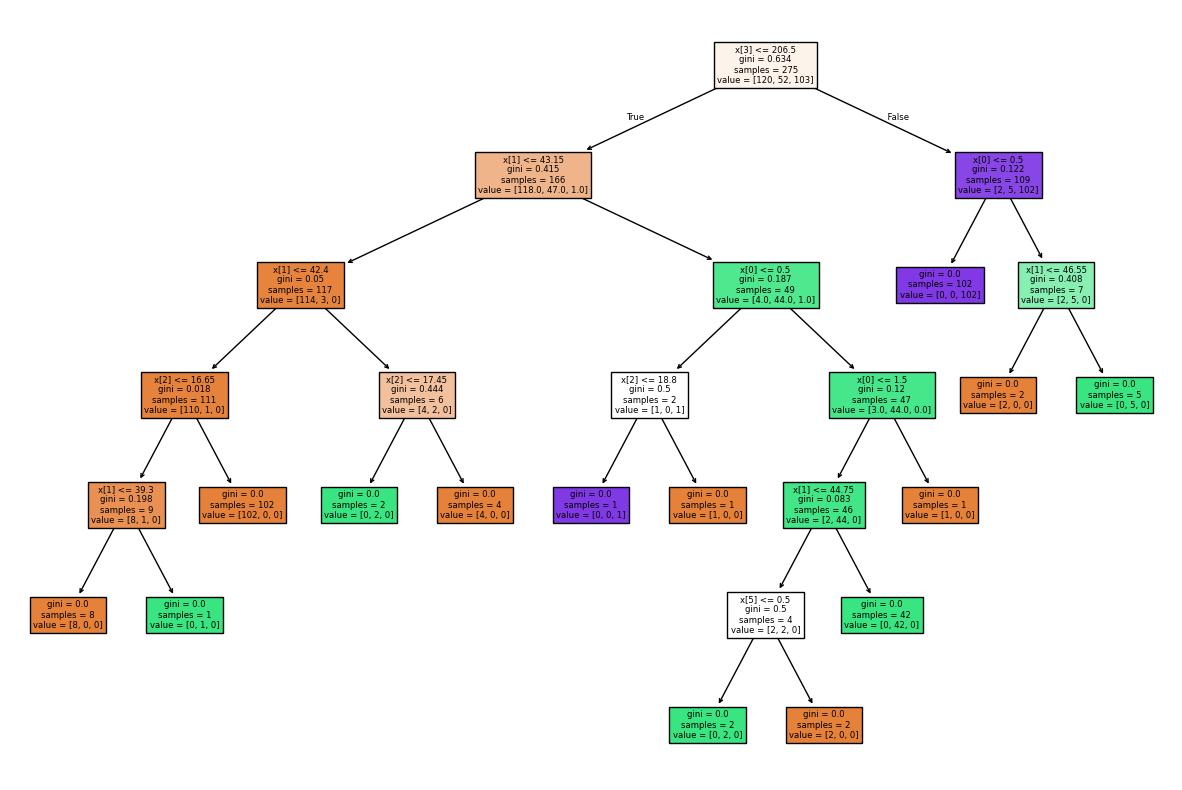

In [88]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treeclassifier,filled=True)

In [90]:
y_pred=treeclassifier.predict(X_test)
y_pred

array([1, 1, 2, 1, 2, 2, 2, 2, 0, 2, 2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 0,
       2, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 2, 1, 0, 1, 2, 2, 2, 0,
       0, 0, 2, 0, 0, 1, 0, 2, 2, 0, 0, 1, 0, 1, 1, 2, 1, 0, 2, 0, 2, 1,
       0, 0, 0])

In [94]:
from sklearn.metrics import accuracy_score, classification_report
score = accuracy_score(y_pred, y_test)
print(score)
print(classification_report(y_pred,y_test))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        21

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



In [95]:
model = DecisionTreeClassifier(
    max_depth=3
)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5416666666666666, 0.875, 'x[3] <= 206.5\ngini = 0.634\nsamples = 275\nvalue = [120, 52, 103]'),
 Text(0.3333333333333333, 0.625, 'x[1] <= 43.15\ngini = 0.415\nsamples = 166\nvalue = [118.0, 47.0, 1.0]'),
 Text(0.4375, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'x[1] <= 42.4\ngini = 0.05\nsamples = 117\nvalue = [114, 3, 0]'),
 Text(0.08333333333333333, 0.125, 'gini = 0.018\nsamples = 111\nvalue = [110, 1, 0]'),
 Text(0.25, 0.125, 'gini = 0.444\nsamples = 6\nvalue = [4, 2, 0]'),
 Text(0.5, 0.375, 'x[0] <= 0.5\ngini = 0.187\nsamples = 49\nvalue = [4.0, 44.0, 1.0]'),
 Text(0.4166666666666667, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [1, 0, 1]'),
 Text(0.5833333333333334, 0.125, 'gini = 0.12\nsamples = 47\nvalue = [3.0, 44.0, 0.0]'),
 Text(0.75, 0.625, 'x[2] <= 17.65\ngini = 0.122\nsamples = 109\nvalue = [2, 5, 102]'),
 Text(0.6458333333333333, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 102\nvalue = [0, 0, 102]'),
 Text(0.8333333333333334, 0.37

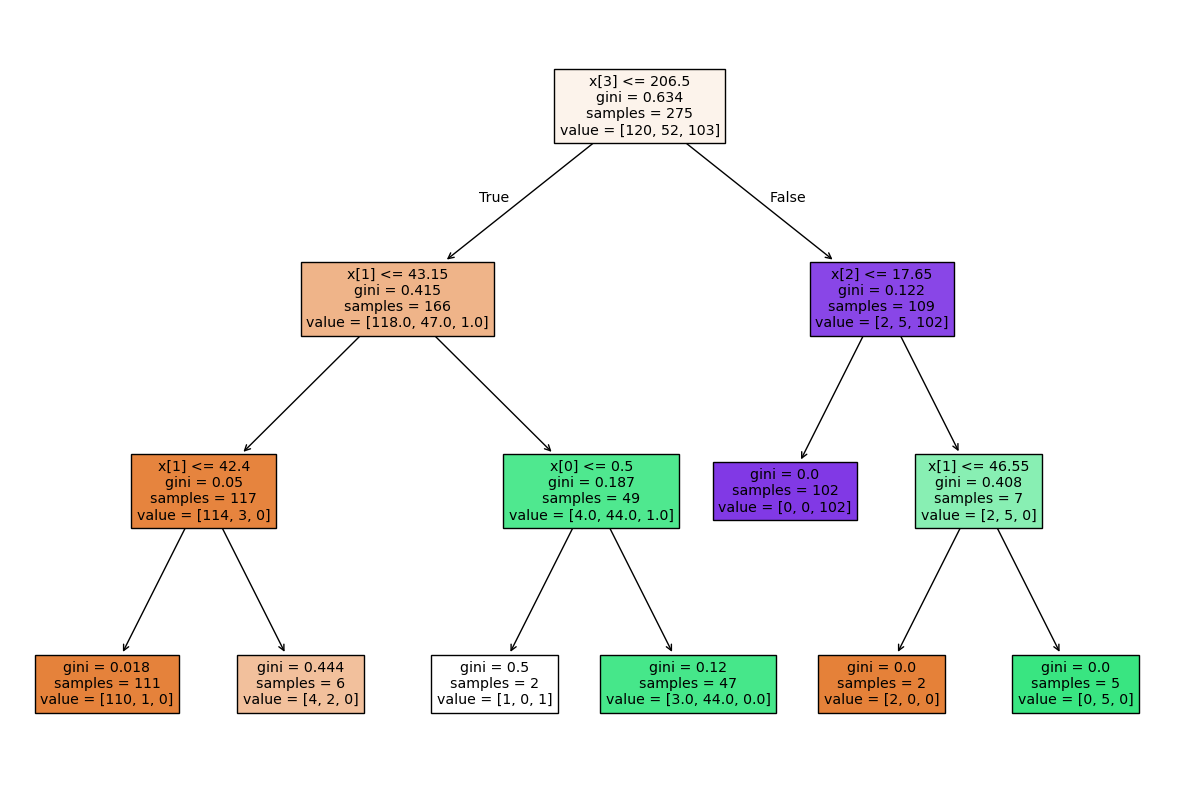

In [96]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(model,filled=True)

In [97]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 2, 1, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 0,
       2, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 2, 1, 0, 1, 2, 2, 2, 0,
       1, 0, 2, 0, 0, 1, 0, 2, 2, 0, 0, 1, 0, 1, 1, 2, 1, 0, 2, 0, 2, 0,
       1, 0, 0])

In [98]:
from sklearn.metrics import accuracy_score, classification_report
score = accuracy_score(y_pred, y_test)
print(score)
print(classification_report(y_pred,y_test))

0.9420289855072463
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        32
           1       0.94      0.88      0.91        17
           2       0.95      1.00      0.98        20

    accuracy                           0.94        69
   macro avg       0.94      0.94      0.94        69
weighted avg       0.94      0.94      0.94        69

